# gridarena LLM System: Tutorial & Usage Guide

This notebook explains how to interact with the **gridarena LLM System** a natural language assistant built on top of the gridarena grid management platform.

The system allows engineers to query and manage electrical grids using plain English, without needing to know specific API endpoints or parameter formats.

### What this notebook covers
- How the system works at a high level
- How to start the system and authenticate
- How to interact with each agent through natural language
- How to interpret raw outputs and LLM interpretations
- Tips for effective prompting
- How the RAG pipeline enhances responses

### Prerequisites
- A valid API key for the INESCTEC private server


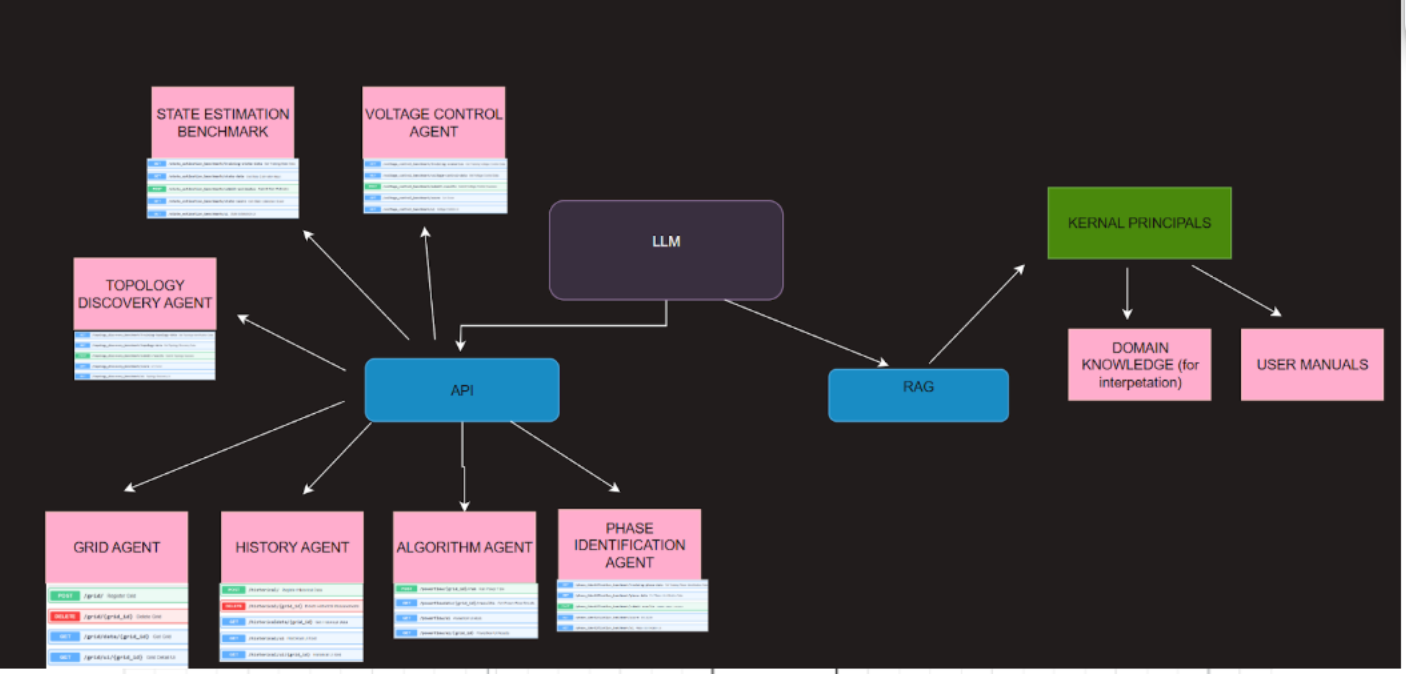

---
## 1. System Architecture

Before using the system, it is worth understanding how a request flows through it.

```
Engineer types a message
        ↓
RAG retriever fetches relevant documentation
        ↓
LLM receives: message + tool schemas + documentation context
        ↓
LLM decides which tool to call and with what arguments
        ↓
Dispatcher routes to the correct agent class
        ↓
Agent calls the real gridarena function (or mock fallback)
        ↓
Raw output displayed to engineer
        ↓
LLM called again to interpret the result in plain English
        ↓
Interpretation displayed below raw output
```

### The 7 Agents

| Agent | What it manages |
|---|---|
| **GridAgent** | Grid registration, deletion, node and connection queries |
| **HistoricalAgent** | Historical measurement upload, deletion, and retrieval |
| **PhaseAgent** | Phase identification training, testing, submission, and scoring |
| **TopologyAgent** | Topology discovery training, testing, submission, and scoring |
| **StateAgent** | State estimation training data, estimation tasks, and scoring |
| **VoltageAgent** | Voltage control scenarios, testing, submission, and scoring |
| **PowerflowAgent** | Power flow execution and result retrieval |

![][image1]

[image1]: <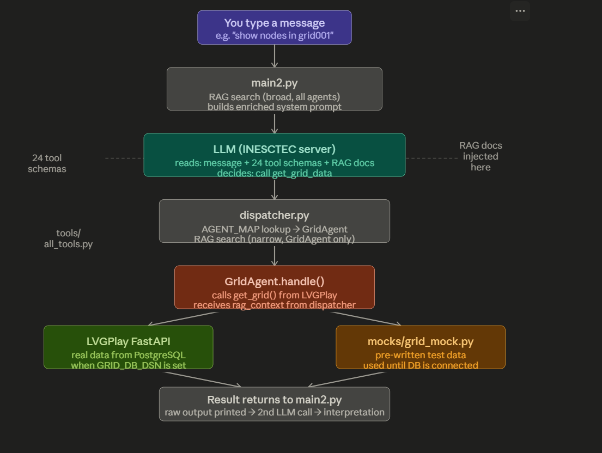>

---
## 3. Calling the System from Python



### 3.1 Calling a tool directly

You can call any tool directly without going through the LLM. This is useful for testing that your agents and database connection are working correctly.

In [ ]:
# Call the GridAgent directly to retrieve nodes from a grid
result = await run_tool(
    tool_name="get_grid_data",
    tool_args={"grid_id": "grid001", "table": "Node"}
)

print(f"Agent:    {result['agent']}")
print(f"Function: {result['function']}")
print()
print(json.dumps(result['output'], indent=2))

In [ ]:
# Retrieve connections for a grid
result = await run_tool(
    tool_name="get_grid_data",
    tool_args={"grid_id": "grid001", "table": "Connection"}
)

print(json.dumps(result['output'], indent=2))

---
## 4. Grid Agent

The **GridAgent** is responsible for registering, querying, and deleting grids. It is typically the starting point for any workflow — before running benchmarks or power flow, a grid must be registered in the system.

### Available tools
| Tool | When to use |
|---|---|
| `register_grid` | Add a new grid from a JSON file |
| `get_grid_data` | Query nodes, connections, cables, or general grid info |
| `delete_grid` | Remove a grid and all its associated data |

### Natural language examples
```
show me the nodes in grid001
what connections does grid001 have?
register a new grid from data/my_grid.json with phase detection for testing
delete grid001
```

In [ ]:
# Query general grid information
result = await run_tool(
    tool_name="get_grid_data",
    tool_args={"grid_id": "grid001", "table": "grids"}
)
print(json.dumps(result['output'], indent=2))

In [ ]:
# Query cables
result = await run_tool(
    tool_name="get_grid_data",
    tool_args={"grid_id": "grid001", "table": "Cable"}
)
print(json.dumps(result['output'], indent=2))

In [ ]:
# Register a new grid
# The JSON file must match the Grid schema:
# { "grid_id": str, "nodes": [...], "connections": [...], "cables": [...] }

result = await run_tool(
    tool_name="register_grid",
    tool_args={
        "file_path": "data/my_grid.json",
        "phase_detection": "TEST_TRAIN",
        "topology_detection": "NONE",
        "voltage_control": "TEST",
        "state_estimation": "NONE"
    }
)
print(json.dumps(result['output'], indent=2))

---
## 5. Historical Agent

The **HistoricalAgent** manages time-series measurement data for grids. This data is used by all benchmark agents for training and testing.

### Available tools
| Tool | When to use |
|---|---|
| `register_historical_data` | Upload measurements from a JSON file |
| `get_historical_data` | Retrieve measurements with optional filters |
| `delete_historical_measurements` | Delete measurements with optional filters |

### Measurement data format
Each measurement record contains:
- `node_id` — the node the measurement belongs to
- `datetime` — ISO 8601 timestamp
- `phase` — electrical phase: R, S, or T
- `power_active` — active power in kW
- `power_reactive` — reactive power in kVAR
- `voltage_magnitude` — voltage magnitude in Volts
- `voltage_angle` — voltage angle in degrees

### Natural language examples
```
show me the historical data for grid001
get measurements for node PT in grid001 from 2025-07-01 to 2025-08-01
get phase R only measurements for grid001
delete all measurements for grid001
```

In [ ]:
# Retrieve all measurements for a grid
result = await run_tool(
    tool_name="get_historical_data",
    tool_args={"grid_id": "grid001"}
)
print(f"Records returned: {result['output'].get('count', 0)}")
print(json.dumps(result['output'], indent=2))

In [ ]:
# Filter measurements by node, phase, and date range
result = await run_tool(
    tool_name="get_historical_data",
    tool_args={
        "grid_id": "grid001",
        "node_id": "PT",
        "phase": "R",
        "start": "2025-07-01T00:00:00",
        "end": "2025-08-01T00:00:00",
        "per_phase": True
    }
)
print(json.dumps(result['output'], indent=2))

---
## 6. Power Flow Agent

The **PowerflowAgent** runs the power flow algorithm on a grid for a specified phase. Power flow computes the voltage magnitude and angle at every node in the grid based on the power injections from historical measurements.

### Available tools
| Tool | When to use |
|---|---|
| `run_power_flow` | Execute the power flow algorithm for a grid and phase |
| `get_power_flow_results` | Retrieve previously computed results |

### How to interpret results
Power flow results return a complex voltage at each node:
- `real` component — the in-phase voltage component
- `imag` component — the quadrature voltage component
- **Voltage magnitude** = √(real² + imag²)
- **Voltage angle** = arctan(imag / real) in degrees

**What to look for:**
- Nominal voltage for a low voltage grid is typically 230V (single phase)
- Voltage magnitude below 0.90 × 230 = **207V** is an undervoltage violation
- Voltage magnitude above 1.1 × 230 = **253V** is an overvoltage violation
- Node PT is the reference node (slack bus) and should always be at nominal voltage
- Voltage typically drops progressively from PT toward the end nodes (N6)

### Natural language examples
```
run power flow for grid001 phase R
run power flow for grid001 phase S from 2025-07-01T00:00:00 to 2025-07-01T23:59:59
get power flow results for grid001 phase R
```

In [ ]:
# Run power flow for all available timestamps
result = await run_tool(
    tool_name="run_power_flow",
    tool_args={"grid_id": "grid001", "phase": "R"}
)
print(result['output']['message'])

In [ ]:
# Run power flow for a specific time range
result = await run_tool(
    tool_name="run_power_flow",
    tool_args={
        "grid_id": "grid001",
        "phase": "R",
        "start_time": "2025-07-01T00:00:00",
        "end_time": "2025-07-01T23:59:59"
    }
)
print(result['output']['message'])

In [ ]:
import math

# Retrieve and interpret power flow results
result = await run_tool(
    tool_name="get_power_flow_results",
    tool_args={"grid_id": "grid001", "phase": "R"}
)

NOMINAL = 230.0
LOWER_LIMIT = 0.95 * NOMINAL  # 218.5V
UPPER_LIMIT = 1.05 * NOMINAL  # 241.5V

print(f"Grid: {result['output']['grid_id']}  Phase: {result['output']['phase']}")
print(f"{'Timestamp':<22} {'Node':<8} {'|V| (V)':<12} {'Angle (°)':<12} Status")
print("-" * 70)

for r in result['output']['results']:
    real = r['voltage']['real']
    imag = r['voltage']['imag']
    magnitude = math.sqrt(real**2 + imag**2)
    angle = math.degrees(math.atan2(imag, real))
    
    if magnitude < LOWER_LIMIT:
        status = "⚠ UNDERVOLTAGE"
    elif magnitude > UPPER_LIMIT:
        status = "⚠ OVERVOLTAGE"
    else:
        status = "✓ OK"
    
    print(f"{str(r['timestamp']):<22} {r['node_id']:<8} {magnitude:<12.2f} {angle:<12.2f} {status}")

---
## 7. Phase Identification Agent

The **PhaseAgent** supports the phase identification benchmark. The goal is to identify which electrical phase (R, S, or T) each node belongs to, given only anonymised measurement data.

### Workflow
1. Download training data (labelled — phases visible)
2. Train your algorithm
3. Download test data (anonymised — phases hidden)
4. Run your algorithm on the test data
5. Submit your phase guesses
6. Check your accuracy score

### Available tools
| Tool | When to use |
|---|---|
| `get_training_phase_data` | Get labelled training data |
| `get_phase_identification_data` | Get anonymised test data |
| `submit_phase_guesses` | Submit your guesses |
| `get_phase_score` | Check your accuracy |

### Difficulty levels
| Level | Description |
|---|---|
| `clean` | No noise added to measurements |
| `easy` | Low noise — minor perturbations |
| `medium` | Moderate noise |
| `hard` | High noise — measurements significantly corrupted |

### Natural language examples
```
get clean training data for phase identification
get hard difficulty phase identification test data
submit phase guesses for grid001 with user id user001: anon_key_a1b2 is R, anon_key_c3d4 is S
what is the phase identification score for user001 on grid001?
```

In [ ]:
# Get clean training data
result = await run_tool(
    tool_name="get_training_phase_data",
    tool_args={"difficulty": "clean"}
)

grids = result['output']['grids']
print(f"Difficulty: {result['output']['difficulty']}")
print(f"Grids available: {list(grids.keys())}")
for grid_id, nodes in grids.items():
    print(f"  {grid_id}: {len(nodes)} nodes")

In [ ]:
# Get anonymised test data (phases hidden)
result = await run_tool(
    tool_name="get_phase_identification_data",
    tool_args={"difficulty": "medium"}
)

grids = result['output']['grids']
print(f"Difficulty: {result['output']['difficulty']}")
for grid_id, anon_keys in grids.items():
    print(f"  {grid_id}: anonymised keys → {list(anon_keys.keys())}")

In [ ]:
# Submit phase guesses
# guesses: { anonymised_key: guessed_phase }
result = await run_tool(
    tool_name="submit_phase_guesses",
    tool_args={
        "guess_id": "user001",
        "grid_id": "grid001",
        "guesses": {
            "anon_key_a1b2": "R",
            "anon_key_c3d4": "S",
            "anon_key_e5f6": "T"
        }
    }
)
print(result['output'])

In [ ]:
# Check score
result = await run_tool(
    tool_name="get_phase_score",
    tool_args={"guess_id": "user001", "grid_id": "grid001"}
)
score = result['output']
print(f"User:     {score['guess_id']}")
print(f"Grid:     {score['grid_id']}")
print(f"Accuracy: {score['accuracy'] * 100:.1f}%")

---
## 8. Topology Discovery Agent

The **TopologyAgent** supports the topology discovery benchmark. The goal is to identify the connections between nodes in a grid given only measurement data — the wiring is hidden.

### Workflow
1. Download training data (includes true topology as edge list)
2. Train your algorithm
3. Download test data (topology hidden, grid anonymised)
4. Predict the edge list
5. Submit guesses as pairs of node indices
6. Check your score

### How guesses are formatted
Topology guesses are a list of edges, where each edge is a pair of node **indices** (not node IDs). The node-to-index mapping is provided in the training data.

```python
# Example: a linear grid with 6 nodes
guesses = [[0,1], [1,2], [2,3], [3,4], [4,5]]
```

### How to interpret the score
- `accuracy` — fraction of true edges correctly identified (0 to 1)
- `correct` — number of edges guessed correctly
- `incorrect_extra` — edges you guessed that do not exist
- `missed` — real edges you did not guess
- A perfect score has accuracy = 1.0, incorrect_extra = 0, missed = 0

### Natural language examples
```
get clean topology training data
get hard difficulty topology test data
submit topology guesses for grid001 with user id user001: edges 0-1, 1-2, 2-3, 3-4, 4-5
what is the topology score for user001 on grid001?
```

In [ ]:
# Get training data — topology visible
result = await run_tool(
    tool_name="get_training_topology_data",
    tool_args={"difficulty": "clean"}
)

output = result['output']
print(f"Difficulty: {output['difficulty']}")
print()
for grid_id, index_map in output.get('node to corresponding index', {}).items():
    print(f"Grid: {grid_id}")
    print(f"  Node → Index mapping: {index_map}")
    edges = output.get('topology (index)', {}).get(grid_id, [])
    print(f"  True edges: {edges}")

In [ ]:
# Submit topology guesses
result = await run_tool(
    tool_name="submit_topology_guesses",
    tool_args={
        "guess_id": "user001",
        "grid_id": "grid001",
        "guesses": [[0,1], [1,2], [2,3], [3,4], [4,5]]
    }
)
print(result['output'])

In [ ]:
# Check topology score
result = await run_tool(
    tool_name="get_topology_score",
    tool_args={"guess_id": "user001", "grid_id": "grid001"}
)
score = result['output']
print(f"User:              {score['guess_id']}")
print(f"Grid:              {score['grid_id']}")
print(f"Accuracy:          {score['accuracy'] * 100:.1f}%")
print(f"Correct edges:     {score['correct']} / {score['total_true_edges']}")
print(f"Extra (wrong):     {score['incorrect_extra']}")
print(f"Missed:            {score['missed']}")

---
## 9. State Estimation Agent

The **StateAgent** supports the state estimation benchmark. The goal is to estimate the voltage magnitude and angle at unobservable nodes, given measurements from observable nodes and historical data.

### Workflow
1. Download training data (all nodes observable, masked IDs)
2. Download an estimation input task (some nodes hidden)
3. Use historical data and known nodes to estimate unknown voltages
4. Submit estimates
5. Check your score (sum of squared errors)

### Key concepts
- **Masked IDs** — both grid and node identifiers are anonymised. You receive `masked_grid_id` and `masked_node_id` values, not real IDs
- **Known nodes** — nodes with measurements at the current timestamp
- **Unknown nodes** — nodes whose voltages you need to estimate
- **Estimation Task ID** — a unique identifier for each task, needed when submitting

### How to interpret the score
The score is the **sum of squared errors** between your predicted voltages and the true voltages:
- Lower is better
- Score = 0.0 is a perfect prediction
- Typical acceptable scores depend on the number of unknown nodes and noise level

### Natural language examples
```
get state estimation training data
get state estimation input for user user001
what is the state estimation score for user001 on task est_task_abc123?
```

In [ ]:
# Get training data
result = await run_tool(
    tool_name="get_training_state_data",
    tool_args={"noise_difficulty": "clean", "observability": "medium"}
)

output = result['output']
print(f"Noise difficulty: {output['noise_difficulty']}")
grids = output.get('grids', {})
for grid_id, nodes in grids.items():
    print(f"  Masked grid: {grid_id} — {len(nodes)} masked nodes")

In [ ]:
# Get an estimation task
result = await run_tool(
    tool_name="get_state_estimation_input",
    tool_args={"user_id": "user001", "noise_difficulty": "clean", "observability": "medium"}
)

output = result['output']
print(f"Masked Grid ID:     {output['Masked GridID']}")
print(f"Estimation Task ID: {output['Estimation Task ID']}")
print(f"Known nodes:        {list(output['Current State']['known_nodes'].keys())}")
print(f"Unknown nodes:      {output['Current State']['unknown_nodes']}")

In [ ]:
# Submit voltage estimates for unknown nodes
# Replace masked_node_ids and estimation_id with values from the task above
result = await run_tool(
    tool_name="submit_state_estimates",
    tool_args={
        "user_id": "user001",
        "estimation_id": "est_task_abc123",
        "grid_id": "masked_grid_001",
        "timestamp": "2025-07-01T12:00:00",
        "estimates": [
            {"masked_node_id": "masked_node_N3_R", "voltage_magnitude": 229.0, "voltage_angle": 29.8},
            {"masked_node_id": "masked_node_N4_S", "voltage_magnitude": 227.0, "voltage_angle": 28.9}
        ]
    }
)
print(result['output'])

In [ ]:
# Check state estimation score
result = await run_tool(
    tool_name="get_state_estimation_score",
    tool_args={"user_id": "user001", "estimation_id": "est_task_abc123"}
)
score = result['output']
print(f"User:           {score['user_id']}")
print(f"Estimation ID:  {score['estimation_id']}")
print(f"Score (SSE):    {score['score']}")
print()
print("Note: Lower score = better. 0.0 = perfect prediction.")

---
## 10. Voltage Control Agent

The **VoltageAgent** supports the voltage control benchmark. The goal is to correct voltage violations by proposing adjusted voltages and power settings for nodes that are outside the acceptable range.

### Workflow
1. Download training scenarios (includes reference solutions)
2. Learn from the reference solutions
3. Download test data (solutions hidden)
4. Propose corrected voltages and power adjustments
5. Submit guesses
6. Check your score

### Scenario types
- **Overvoltages**: snapshots where at least one node exceeds the voltage limit
- **Undervoltages**: snapshots where at least one node is below the voltage limit

### How to interpret the score
The scoring system rewards two things:
- **Voltage correction**: how close your corrected voltages are to the reference solution
- **Effort efficiency**: minimal changes to active power (large unnecessary changes are penalised)
- Score ranges from 0 to 1, higher is better
- A score of 1.0 means you matched the reference solution with minimal effort

### Natural language examples
```
get training voltage control data for overvoltages with voltage limit 230
get hard difficulty undervoltage test data with limit 220
what is the voltage control score for user001 on grid001?
```

In [ ]:
# Get training scenarios for overvoltages
result = await run_tool(
    tool_name="get_training_voltage_control_data",
    tool_args={
        "voltage_limit": 230.0,
        "scenario": "Overvoltages",
        "difficulty": "clean"
    }
)

output = result['output']
print(f"Scenario:   {output['scenario']}")
print(f"Difficulty: {output['difficulty']}")
print(f"Voltage limit: {output['voltage_limit']}V")
for grid_id, timestamps in output.get('grids', {}).items():
    print(f"  {grid_id}: {len(timestamps)} snapshots")

In [ ]:
# Check voltage control score
result = await run_tool(
    tool_name="get_voltage_control_score",
    tool_args={"guess_id": "user001", "grid_id": "grid001"}
)
score = result['output']
print(f"User:           {score['guess_id']}")
print(f"Grid:           {score['grid_id']}")
print(f"Overall score:  {score['overall_score'] * 100:.1f}%")
print(f"Total nodes:    {score['total_nodes']}")

---
## 11. Using the Natural Language Interface

All of the above can be done through plain English in the chat interface. This section shows how to phrase requests effectively.

### 11.1 Effective Prompting Tips

**Be specific about grid IDs and user IDs:**
```
✓ show me the nodes in grid001
✗ show me the nodes in the grid
```

**Include the parameters you want:**
```
✓ get hard difficulty phase identification test data
✗ get phase data
```

**Ask for interpretation explicitly if you want domain context:**
```
✓ run power flow for grid001 phase R and explain the results
✓ what does a voltage below 0.95 pu mean for node N6?
```

**Use the conversation context:**
```
You:       run power flow for grid001 phase R
Assistant: [runs power flow, shows results]
You:       now do the same for phase S
```
The system remembers earlier context within a session.

**Ask general questions without triggering tool calls:**
```
✓ what is the difference between clean and hard difficulty?
✓ how do I interpret a topology score?
✓ what parameters does submit_phase_guesses need?
```
These questions use RAG-retrieved documentation and do not call any tools.

### 11.2 Understanding the Output Format

Every tool response is displayed in two sections:

```
--- RAW OUTPUT ---
Agent:    PowerflowAgent
Function: get_power_flow_results
Input:    { "grid_id": "grid001", "phase": "R" }
Output:   { ... full JSON response ... }
------------------

--- INTERPRETATION ---
The power flow results for grid001 phase R show that node PT
is at nominal voltage (230V). Nodes N5 and N6 show a voltage
drop of approximately 5.8V which is within acceptable limits.
----------------------
```

- **RAW OUTPUT**: the exact data returned by the gridarena function
- **INTERPRETATION**: the LLM's domain-aware explanation of the result

You can collapse the raw output in the web interface by clicking the panel header.

---
## 12. RAG Pipeline

The system uses **Retrieval-Augmented Generation (RAG)** to give the LLM domain knowledge about the gridarena system. Before the LLM interprets a result, relevant documentation is retrieved from a vector database and injected into the context.

### What this means in practice
- The LLM knows what voltage thresholds are acceptable
- The LLM knows what each field in the response means
- The LLM knows when a score is good or needs attention
- The LLM can answer questions about how functions work without calling them

### Rebuilding the vector database
The main script (INESCTEC.py) now automatically rebuilds the vectordatabase for each iteration)

---
## 13. Model Selection

The system supports multiple models on the INESCTEC private server. Currently only gemma4-31b is supported. 


### Temperature
Temperature controls the randomness of the LLM output:
- **0.0–0.3**: deterministic, consistent answers (recommended for tool calling)
- **0.5–0.8**: more varied, creative responses
- **1.0+**: very random, not recommended for technical queries

The default temperature is **0.3**, which balances consistency with natural language quality.

---
## 14. Troubleshooting



### The LLM fails to call a tool correctly
This occasionally happens with smaller models when parameters have complex types. Try:
- Rephrasing your request more explicitly
- Including the parameter values explicitly: `"with voltage limit 230.0"`



---
## Summary

The gridarena LLM System provides a complete natural language interface over the gridarena grid management platform. Key points:

- **7 agents, 24 tools** covering all grid management and benchmark operations
- **Natural language** — ask questions in plain English, no API knowledge required
- **RAG pipeline** — domain knowledge from documentation enhances every response
- **Mock fallback** — works without a live database for development and testing
- **Model agnostic** — switch between all avaliable agents without writing any new code
- **Two-stage output** — raw data always displayed separately from interpretation


For questions about the gridarena platform itself, refer to the individual benchmark notebooks:
- `Historical_Benchmark.ipynb`
- `Phase_Detection_Benchmark.ipynb`
- `Topology_Discovery_Benchmark.ipynb`
- `State_Estimation_Benchmark.ipynb`
- `Voltage_Control_Benchmark.ipynb`
- `Powerflow_Benchmark.ipynb`

For questions about how to expand the gridarena LLM System, refer to the developer guide:
- `Developer_guide.ipynb`